In [45]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as img

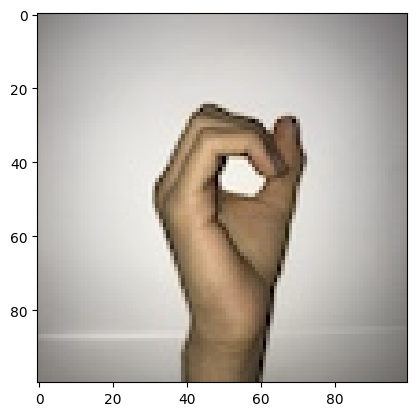

In [46]:
# Verificiar el dataset
imagen = img.imread('Sign-Language-Digits-Dataset/Examples/example_0.JPG')
plt.imshow(imagen)
plt.show()

<BarContainer object of 10 artists>

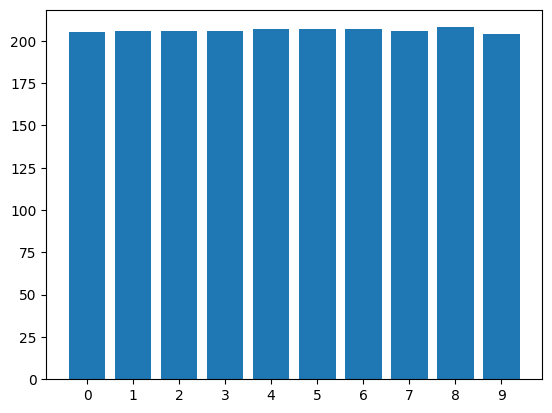

In [47]:
import os 
# Análisis descriptivo con gráficos
ruta_base = 'Sign-Language-Digits-Dataset/Dataset'
clases = sorted(os.listdir(ruta_base)) # Devuelve una lista con todas las rutas dentro de Dataset ej: ['0', '1', '2', '3', ...]

# Crear listas donde guardar los nombres de cada clase y la cantidad en cada una
nombres = []
cantidad = []

# Recorrer las subcarpetas y guardar la cantidad y nombres en las listas.
for clase in clases:
    ruta_clase = os.path.join(ruta_base, clase)
    cantidad.append(len(os.listdir(ruta_clase))) # Verificar cuantos archivos hay en la ruta de ruta_clase, que seria inicialmente Sign-Language-Digits-Dataset/Dataset/0, contarlos y agregarlos a la lista cantidad
    nombres.append(clase)

# Graficar con plt.bar
plt.bar(nombres, cantidad)

# El dataset contiene 2062 imágenes distribuidas en 10 clases (~205 c/u), como muestra el gráfico de barras. La distribución es prácticamente uniforme, por lo que el conjunto está balanceado.

In [62]:
# Determinar los datos para entrenamiento, validación y prueba.
datos_train = tf.keras.utils.image_dataset_from_directory(
    'Sign-Language-Digits-Dataset/Dataset',
    image_size=(64,64),
    batch_size=32,
    seed=42,
    validation_split=0.3,
    subset='training'
)

datos_restantes = tf.keras.utils.image_dataset_from_directory(
    'Sign-Language-Digits-Dataset/Dataset',
    image_size=(64,64),
    batch_size=32,
    seed=42,
    validation_split=0.3,
    subset='validation'
)

val_batches = tf.data.experimental.cardinality(datos_restantes)
datos_val = datos_restantes.take(val_batches // 2)
datos_test = datos_restantes.skip(val_batches // 2) # metodo skip para que no sean los mismos que datos_val


Found 2062 files belonging to 10 classes.
Using 1444 files for training.
Found 2062 files belonging to 10 classes.
Using 618 files for validation.


In [63]:
# Normalizar
datos_train = datos_train.map(lambda x, y: (x / 255.0, y))
datos_val = datos_val.map(lambda x, y: (x / 255.0, y))
datos_test = datos_test.map(lambda x, y: (x / 255.0, y))

In [ ]:
# Crear modelo
modelo = tf.keras.Sequential([
    # Forma de la entrada
    tf.keras.layers.Input(shape=(64,64,3)), # 64x64 pixeles con 3 canales rgb
    # Implementar data augmentation (rotar las imagenes y hacer zoom para tener más variantes)
    tf.keras.layers.RandomRotation(0.05), # 15 grados aprox
    tf.keras.layers.RandomZoom(0.1), # 10%

    # Detectar patrones (curvas, formas, etc) usando redes convolucionales se hace en dos dimensiones.
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'), # 32 filtros, se usarian 32 mapas y estos tienen un tamaño aprox del tamaño de la imagen que es de 64x64 pixeles aprox, por lo que lo achicamos con maxpooling
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    # Otra capa más para detectar patrones más complejos.
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'), # Habrian 64 mapas de 32x32 pixeles aprox por los filtros anteriores por el uso de maxpooling
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)), # los 64 mapas se achican a 16x16 pixeles

    # Aplanar para usar los datos en la capa Dense, que solo acepta datos de forma lineal (1D)
    tf.keras.layers.Flatten(),
    # Capa Dense
    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.Dense(units=10, activation='softmax')
])


In [65]:
modelo.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_6               │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_6 (RandomZoom)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [83]:
# Configurar como va a aprender la red
modelo.compile(loss='sparse_categorical_crossentropy', 
               optimizer='adam', 
               metrics=['accuracy'])

In [ ]:
# Implementar early stopping para cuando el modelo ya no esté aprendiendo, este pare, cuando el loss de validación deje de mejorar.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4, # Cuantos epochs espera sin mejora antes de parar
    restore_best_weights=True # Se queda con los pesos del mejor momento
)

modelo.fit(
    datos_train,
    validation_data=datos_val,
    epochs=1000,
    callbacks=[early_stop]
)

Epoch 1/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2181 - loss: 2.1876 - val_accuracy: 0.4563 - val_loss: 1.6089
Epoch 2/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5727 - loss: 1.3165 - val_accuracy: 0.6906 - val_loss: 0.8232
Epoch 3/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6794 - loss: 0.9656 - val_accuracy: 0.7500 - val_loss: 0.6993
Epoch 4/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7361 - loss: 0.8073 - val_accuracy: 0.8094 - val_loss: 0.5430
Epoch 5/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7701 - loss: 0.7201 - val_accuracy: 0.8219 - val_loss: 0.5180
Epoch 6/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7985 - loss: 0.6061 - val_accuracy: 0.8656 - val_loss: 0.4598
Epoch 7/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8407 - loss: 0.5325 - val_accuracy: 0.8469 - val_loss: 0.4853
Epoch 8/1000
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8234 - loss: 0.5348 - val_accuracy: 0.

In [85]:
# Testear
resultado = modelo.evaluate(datos_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9228 - loss: 0.2464


In [ ]:
# Guardar modelo
modelo.save('modelo_base.keras')

In [ ]:
# Cargar modelo
modelo_cargado = tf.keras.models.load_model('modelo_base.keras')